In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('heart.csv')

In [6]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [7]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


# Exploratory Data Analysis

In [8]:
# missing values

In [9]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [10]:
# Here there are not missing values

In [11]:
# Checking class distribution

In [12]:
# Count of each class
print(df['target'].value_counts())

# Percentage of each class
print(df['target'].value_counts(normalize=True) * 100)

target
1    526
0    499
Name: count, dtype: int64
target
1    51.317073
0    48.682927
Name: proportion, dtype: float64


In [13]:
# visulaizing

C:\Users\osged\AppData\Local\Temp\ipykernel_8360\164825388.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='Set2')


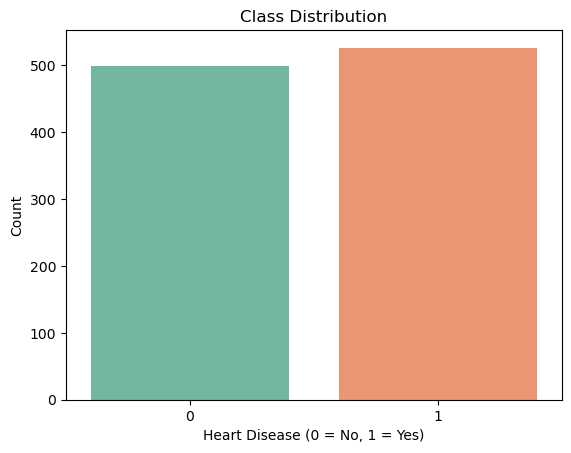

In [14]:

sns.countplot(x='target', data=df, palette='Set2')
plt.title("Class Distribution")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

# Here it is a balanced dataset so procedding normally

In [21]:
#Class Distribution by Sex


In [16]:
# By Sex

print(df.groupby('sex')['target'].value_counts())

# Percentage
print(df.groupby('sex')['target'].value_counts(normalize=True) * 100)

sex  target
0    1         226
     0          86
1    0         413
     1         300
Name: count, dtype: int64
sex  target
0    1         72.435897
     0         27.564103
1    0         57.924264
     1         42.075736
Name: proportion, dtype: float64


In [17]:
# Visulaize

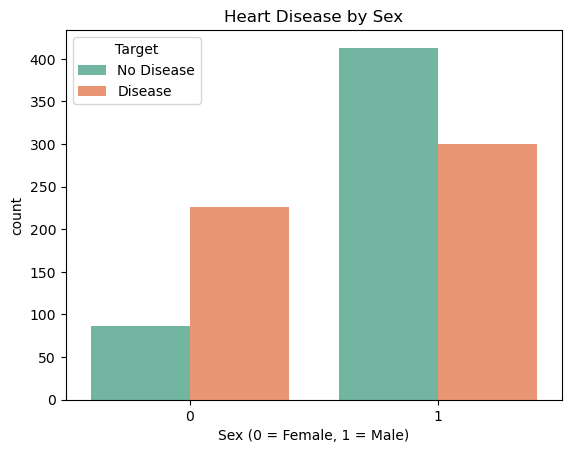

In [18]:
sns.countplot(x='sex', hue='target', data=df, palette='Set2')
plt.title("Heart Disease by Sex")
plt.xlabel("Sex (0 = Female, 1 = Male)")
plt.legend(title='Target', labels=['No Disease', 'Disease'])
plt.show()

In [20]:
# Here female has more heart disease in females
# males have less heart disease in males

In [22]:
print(df.columns.tolist())

['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Define X and y
X = df[['age', 'chol', 'trestbps', 'thalach', 'oldpeak']]
y = df['target']

In [24]:
# 75:25 Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,      # 25% test
    random_state=42,
    stratify=y           # ← important for classification!
)

print(f"Total rows    : {len(df)}")
print(f"Training rows : {len(X_train)}")   # 75%
print(f"Testing rows  : {len(X_test)}")    # 25%


Total rows    : 1025
Training rows : 768
Testing rows  : 257


In [25]:
# Check class balance is maintained after split
print("\nTrain class distribution:")
print(y_train.value_counts())
print("\nTest class distribution:")
print(y_test.value_counts())


Train class distribution:
target
1    394
0    374
Name: count, dtype: int64

Test class distribution:
target
1    132
0    125
Name: count, dtype: int64


In [26]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

In [27]:
y_pred

array([0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1,
       0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1,
       0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1])

In [28]:
# Evaluate
print("=== Model Evaluation ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['No Disease', 'Disease']))

=== Model Evaluation ===
Accuracy : 73.54%

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.75      0.69      0.72       125
     Disease       0.73      0.78      0.75       132

    accuracy                           0.74       257
   macro avg       0.74      0.73      0.73       257
weighted avg       0.74      0.74      0.73       257



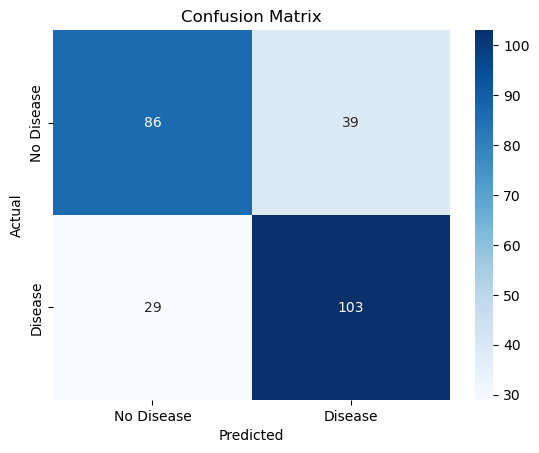

In [29]:
# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease','Disease'],
            yticklabels=['No Disease','Disease'])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [31]:
# New patient data
new_patient = pd.DataFrame({
    'age'      : [52],
    'chol'     : [240],
    'trestbps' : [145],
    'thalach'  : [130],
    'oldpeak'  : [2.3]
})

# Predict class (0 or 1)
prediction = model.predict(new_patient)

# Predict probability
probability = model.predict_proba(new_patient)

print("=== Prediction Result ===")
print(f"Prediction  : {prediction[0]}")
print(f"Probability : No Disease = {probability[0][0]*100:.2f}%")
print(f"            : Disease    = {probability[0][1]*100:.2f}%")

if prediction[0] == 1:
    print("\n⚠️  Result : Heart Disease DETECTED")
else:
    print("\n✅  Result : No Heart Disease")

=== Prediction Result ===
Prediction  : 0
Probability : No Disease = 83.27%
            : Disease    = 16.73%

✅  Result : No Heart Disease


# Here the patient has no heart diease